In [ ]:
# --- Core Libraries ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Sklearn ---
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score,
    recall_score, f1_score,
    roc_curve, roc_auc_score
)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['font.size'] = 12

# ── Load & Split ──────────────────────────────────────────
data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ── Scale ─────────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ── Find Best K (replicates demo) ────────────────────────
test_accuracies = []
for k in range(1, 31):
    m = KNeighborsClassifier(n_neighbors=k)
    m.fit(X_train_scaled, y_train)
    test_accuracies.append(m.score(X_test_scaled, y_test))

best_k = list(range(1, 31))[np.argmax(test_accuracies)]

# ── Baseline Model ────────────────────────────────────────
best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_train_scaled, y_train)
y_pred_best = best_knn.predict(X_test_scaled)

baseline_acc = accuracy_score(y_test, y_pred_best)
baseline_f1  = f1_score(y_test, y_pred_best)
TN, FP, FN, TP = confusion_matrix(y_test, y_pred_best).ravel()

print(f"✅ Setup complete. Best K = {best_k}")
print(f"   Baseline Accuracy : {baseline_acc*100:.2f}%")
print(f"   Baseline F1-Score : {baseline_f1*100:.2f}%")
print(f"   FN (False Negatives): {FN}")

✅ Setup complete. Best K = 9
   Baseline Accuracy : 96.49%
   Baseline F1-Score : 97.18%
   FN (False Negatives): 2


In [ ]:
# ── Train on UNSCALED data using best_k ──────────────────
knn_unscaled = KNeighborsClassifier(n_neighbors=best_k)
knn_unscaled.fit(X_train, y_train)          # raw X_train (no scaling)
y_pred_unscaled = knn_unscaled.predict(X_test)

unscaled_acc = accuracy_score(y_test, y_pred_unscaled)
unscaled_f1  = f1_score(y_test, y_pred_unscaled)

print("─" * 50)
print(f"{'Metric':<20} {'Scaled':>12} {'Unscaled':>12}")
print("─" * 50)
print(f"{'Accuracy':<20} {baseline_acc*100:>11.2f}% {unscaled_acc*100:>11.2f}%")
print(f"{'F1-Score':<20} {baseline_f1*100:>11.2f}% {unscaled_f1*100:>11.2f}%")
print("─" * 50)
print(f"\nAccuracy drop due to no scaling: {(baseline_acc - unscaled_acc)*100:.2f}%")

──────────────────────────────────────────────────
Metric                     Scaled     Unscaled
──────────────────────────────────────────────────
Accuracy                   96.49%       95.61%
F1-Score                   97.18%       96.55%
──────────────────────────────────────────────────

Accuracy drop due to no scaling: 0.88%


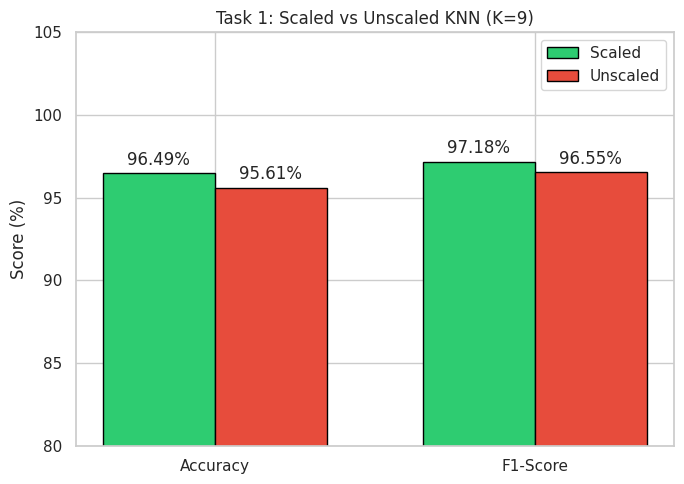

In [ ]:
# ── Visualise the comparison ──────────────────────────────
metrics_labels = ['Accuracy', 'F1-Score']
scaled_vals   = [baseline_acc*100, baseline_f1*100]
unscaled_vals = [unscaled_acc*100, unscaled_f1*100]

x = np.arange(len(metrics_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 5))
bars1 = ax.bar(x - width/2, scaled_vals,   width, label='Scaled',   color='#2ecc71', edgecolor='black')
bars2 = ax.bar(x + width/2, unscaled_vals, width, label='Unscaled', color='#e74c3c', edgecolor='black')

ax.bar_label(bars1, fmt='%.2f%%', padding=3)
ax.bar_label(bars2, fmt='%.2f%%', padding=3)
ax.set_ylim(80, 105)
ax.set_xticks(x)
ax.set_xticklabels(metrics_labels)
ax.set_ylabel('Score (%)')
ax.set_title(f'Task 1: Scaled vs Unscaled KNN (K={best_k})')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ── Four configurations to compare ───────────────────────
configs = [
    {'label': 'Baseline\n(uniform, Euclidean)',  'weights': 'uniform',  'p': 2},
    {'label': 'Distance Weights\n(Euclidean)',   'weights': 'distance', 'p': 2},
    {'label': 'Manhattan\n(uniform)',            'weights': 'uniform',  'p': 1},
    {'label': 'Distance Weights\n(Manhattan)',   'weights': 'distance', 'p': 1},
]

results = []
print(f"{'Configuration':<35} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1-Score':>10}")
print("─" * 80)

for cfg in configs:
    m = KNeighborsClassifier(n_neighbors=best_k, weights=cfg['weights'], p=cfg['p'])
    m.fit(X_train_scaled, y_train)
    yp = m.predict(X_test_scaled)
    row = {
        'label':     cfg['label'].replace('\n', ' '),
        'accuracy':  accuracy_score(y_test, yp),
        'precision': precision_score(y_test, yp),
        'recall':    recall_score(y_test, yp),
        'f1':        f1_score(y_test, yp),
    }
    results.append(row)
    print(f"{row['label']:<35} {row['accuracy']*100:>9.2f}% {row['precision']*100:>9.2f}% "
          f"{row['recall']*100:>9.2f}% {row['f1']*100:>9.2f}%")

Configuration                         Accuracy  Precision     Recall   F1-Score
────────────────────────────────────────────────────────────────────────────────
Baseline (uniform, Euclidean)           96.49%     97.18%     97.18%     97.18%
Distance Weights (Euclidean)            96.49%     97.18%     97.18%     97.18%
Manhattan (uniform)                     96.49%     97.18%     97.18%     97.18%
Distance Weights (Manhattan)            96.49%     97.18%     97.18%     97.18%


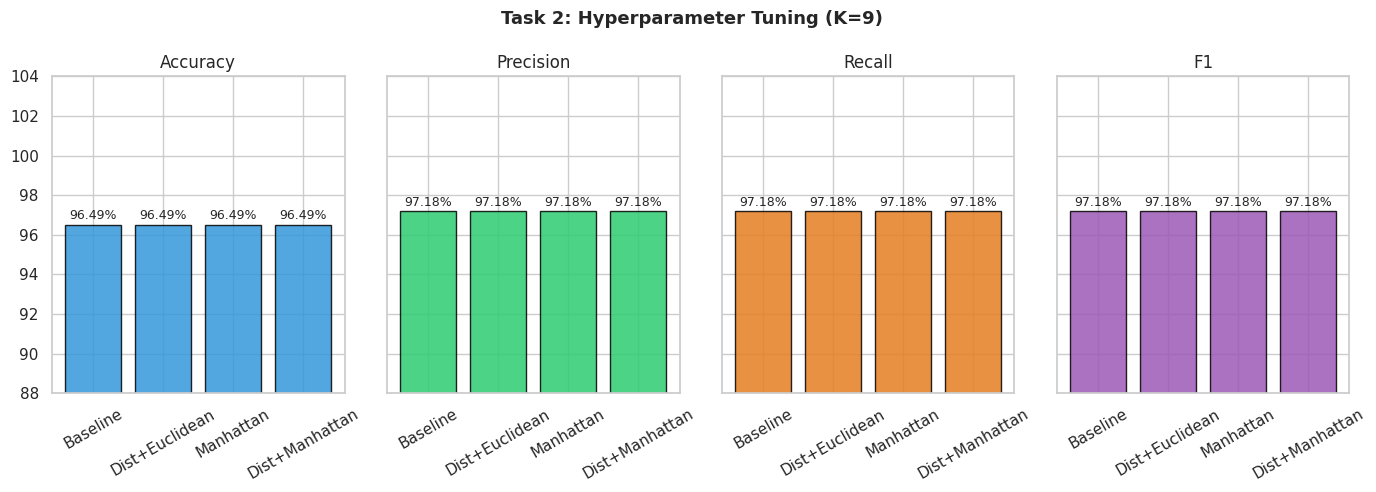

In [ ]:
# ── Grouped bar chart for Task 2 ─────────────────────────
labels_short = ['Baseline', 'Dist+Euclidean', 'Manhattan', 'Dist+Manhattan']
metrics_t2   = ['accuracy', 'precision', 'recall', 'f1']
colors_t2    = ['#3498db', '#2ecc71', '#e67e22', '#9b59b6']

x2 = np.arange(len(labels_short))
fig, axes = plt.subplots(1, 4, figsize=(14, 5), sharey=True)

for ax, metric, color in zip(axes, metrics_t2, colors_t2):
    vals = [r[metric]*100 for r in results]
    bars = ax.bar(labels_short, vals, color=color, edgecolor='black', alpha=0.85)
    ax.bar_label(bars, fmt='%.2f%%', padding=2, fontsize=9)
    ax.set_title(metric.capitalize())
    ax.set_ylim(88, 104)
    ax.tick_params(axis='x', rotation=30)

fig.suptitle(f'Task 2: Hyperparameter Tuning (K={best_k})', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ── Sweep K=1..30, record FN, Recall, Precision ──────────
fn_results = []
for k in range(1, 31):
    m = KNeighborsClassifier(n_neighbors=k)
    m.fit(X_train_scaled, y_train)
    yp = m.predict(X_test_scaled)
    tn, fp, fn, tp = confusion_matrix(y_test, yp).ravel()
    fn_results.append({
        'k': k, 'FN': fn, 'FP': fp,
        'recall':    recall_score(y_test, yp),
        'precision': precision_score(y_test, yp),
        'f1':        f1_score(y_test, yp),
    })

fn_df = pd.DataFrame(fn_results)

# Best K for lowest FN (use highest recall as tiebreak)
min_fn = fn_df['FN'].min()
best_recall_k = fn_df[fn_df['FN'] == min_fn].sort_values('recall', ascending=False).iloc[0]

print(f"Minimum False Negatives achievable: {int(min_fn)}")
print(f"Best K for lowest FN: K={int(best_recall_k['k'])}")
print(f"  Recall    : {best_recall_k['recall']*100:.2f}%")
print(f"  Precision : {best_recall_k['precision']*100:.2f}%")
print(f"  F1-Score  : {best_recall_k['f1']*100:.2f}%")
print()

# Show top-5 K values by lowest FN
print("Top 5 K values ranked by lowest FN:")
print(fn_df.sort_values(['FN', 'k']).head(10).to_string(index=False))

Minimum False Negatives achievable: 1
Best K for lowest FN: K=29
  Recall    : 98.59%
  Precision : 94.59%
  F1-Score  : 96.55%

Top 5 K values ranked by lowest FN:
 k  FN  FP   recall  precision       f1
29   1   4 0.985915   0.945946 0.965517
30   1   4 0.985915   0.945946 0.965517
 9   2   2 0.971831   0.971831 0.971831
11   2   3 0.971831   0.958333 0.965035
12   2   3 0.971831   0.958333 0.965035
13   2   3 0.971831   0.958333 0.965035
14   2   3 0.971831   0.958333 0.965035
15   2   3 0.971831   0.958333 0.965035
16   2   3 0.971831   0.958333 0.965035
17   2   4 0.971831   0.945205 0.958333


In [ ]:

# ── 2-Feature Model (first two columns) ──────────────────
X_train_2f = X_train_scaled[:, :2]
X_test_2f  = X_test_scaled[:, :2]

print(f"Features used: '{data.feature_names[0]}' and '{data.feature_names[1]}'")

knn_2f = KNeighborsClassifier(n_neighbors=best_k)
knn_2f.fit(X_train_2f, y_train)
y_pred_2f = knn_2f.predict(X_test_2f)

acc_2f = accuracy_score(y_test, y_pred_2f)
f1_2f  = f1_score(y_test, y_pred_2f)
rec_2f = recall_score(y_test, y_pred_2f)
prec_2f = precision_score(y_test, y_pred_2f)
tn2, fp2, fn2, tp2 = confusion_matrix(y_test, y_pred_2f).ravel()

print()
print(f"{'Metric':<20} {'Full (30 features)':>20} {'2 Features':>15} {'Difference':>12}")
print("─" * 72)
print(f"{'Accuracy':<20} {baseline_acc*100:>19.2f}% {acc_2f*100:>14.2f}% {(acc_2f - baseline_acc)*100:>+11.2f}%")
print(f"{'F1-Score':<20} {baseline_f1*100:>19.2f}% {f1_2f*100:>14.2f}% {(f1_2f - baseline_f1)*100:>+11.2f}%")
print(f"{'Recall':<20} {recall_score(y_test, y_pred_best)*100:>19.2f}% {rec_2f*100:>14.2f}% {(rec_2f - recall_score(y_test, y_pred_best))*100:>+11.2f}%")
print(f"{'False Negatives':<20} {FN:>20} {fn2:>15}")

Features used: 'mean radius' and 'mean texture'

Metric                 Full (30 features)      2 Features   Difference
────────────────────────────────────────────────────────────────────────
Accuracy                           96.49%          92.98%       -3.51%
F1-Score                           97.18%          94.37%       -2.82%
Recall                             97.18%          94.37%       -2.82%
False Negatives                         2               4


In [ ]:
# ── Decision Boundary Visualisation (possible because 2D) ─
h = 0.02
x_min, x_max = X_train_2f[:, 0].min() - 1, X_train_2f[:, 0].max() + 1
y_min, y_max = X_train_2f[:, 1].min() - 1, X_train_2f[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

Z = knn_2f.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Decision boundary ---
axes[0].contourf(xx, yy, Z, alpha=0.3, cmap='RdYlGn')
scatter = axes[0].scatter(X_test_2f[:, 0], X_test_2f[:, 1],
                          c=y_test, cmap='RdYlGn', edgecolors='black', s=50)
axes[0].set_xlabel(data.feature_names[0])
axes[0].set_ylabel(data.feature_names[1])
axes[0].set_title(f'Task 4: Decision Boundary (K={best_k}, 2 Features)')
plt.colorbar(scatter, ax=axes[0], label='Class (0=Malignant, 1=Benign)')

# --- Performance comparison bar chart ---
metrics_t4  = ['Accuracy', 'F1-Score', 'Recall', 'Precision']
full_vals   = [baseline_acc, baseline_f1,
               recall_score(y_test, y_pred_best),
               precision_score(y_test, y_pred_best)]
two_f_vals  = [acc_2f, f1_2f, rec_2f, prec_2f]

x4 = np.arange(len(metrics_t4))
w  = 0.35
b1 = axes[1].bar(x4 - w/2, [v*100 for v in full_vals],   w, label='30 Features', color='#3498db', edgecolor='black')
b2 = axes[1].bar(x4 + w/2, [v*100 for v in two_f_vals],  w, label='2 Features',  color='#e74c3c', edgecolor='black')
axes[1].bar_label(b1, fmt='%.1f%%', padding=2, fontsize=9)
axes[1].bar_label(b2, fmt='%.1f%%', padding=2, fontsize=9)
axes[1].set_ylim(70, 108)
axes[1].set_xticks(x4)
axes[1].set_xticklabels(metrics_t4)
axes[1].set_ylabel('Score (%)')
axes[1].set_title('Task 4: 30-Feature vs 2-Feature Model')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# ── Confusion Matrix comparison side-by-side ─────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, cm_data, title in zip(
    axes,
    [confusion_matrix(y_test, y_pred_best), confusion_matrix(y_test, y_pred_2f)],
    ['Full Model (30 features)', '2-Feature Model']
):
    sns.heatmap(cm_data, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred Malignant', 'Pred Benign'],
                yticklabels=['Act Malignant', 'Act Benign'])
    ax.set_title(title)

plt.suptitle('Task 4: Confusion Matrix Comparison', fontweight='bold')
plt.tight_layout()
plt.show()